# IE7860 Intelligent Analytics
## MLP Network Assignment

In [1]:
pip install tensorflow scikit-learn matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


In [2]:
## Loading fashion_mnist dataset
from tensorflow import keras
from sklearn.preprocessing import LabelBinarizer
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize x
X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255

# Flatten input
X_train = X_train.reshape([X_train.shape[0], -1])
X_test = X_test.reshape([X_test.shape[0], -1])

print(X_train.shape, y_train.shape)

(60000, 784) (60000,)


Plot some sample images along with their labels.

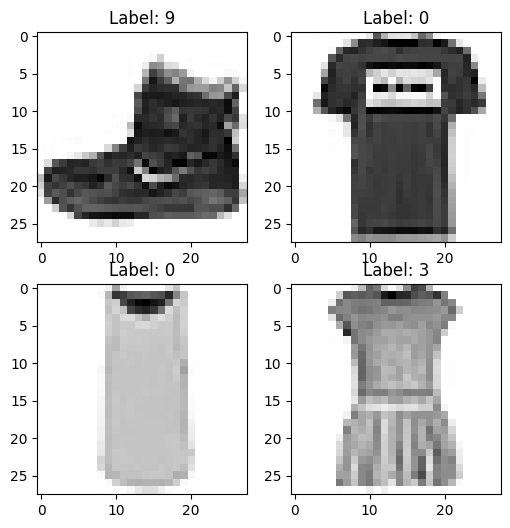

In [3]:
plt.figure(figsize=[6,6])
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.title("Label: %i"%y_train[i])
    plt.imshow(X_train[i].reshape([28,28]),cmap='Greys');

As shown above, the original image data has dimensions N ×( 28 × 28). We flattened each image into a vector, converting the dataset into an array of size N × 784. Next, we apply one-hot encoding to the target variable.

In [4]:
## Changing labels to one-hot encoded vector
lb = LabelBinarizer()
y_train_one_hot = lb.fit_transform(y_train)
y_test_one_hot = lb.transform(y_test)
print('Train labels dimension:');print(y_train_one_hot.shape)
print('Test labels dimension:');print(y_test_one_hot.shape)
print(y_train_one_hot[1000])

Train labels dimension:
(60000, 10)
Test labels dimension:
(10000, 10)
[0 1 0 0 0 0 0 0 0 0]


Now that the data has been processed, we can begin constructing our multi-layer perceptron using TensorFlow. The first step is to import the necessary libraries.

In [5]:
# Define function for plotting history
import matplotlib.pyplot as plt
def plot_metrics(history, metrics =  ['loss', 'accuracy']):
  for n, metric in enumerate(metrics):
    name = metric.replace("_"," ").capitalize()
    #plt.figsize=(20,10)
    plt.subplot(1,len(metrics),n+1)
    plt.tight_layout(pad=2)
    plt.plot(history.epoch,  history.history[metric], color=colors[0], label='Train')
    plt.plot(history.epoch, history.history['val_'+metric],
             color=colors[0], linestyle="--", label='Val')
    plt.xlabel('Epoch')
    plt.ylabel(name)
    plt.legend()

In [6]:
## Importing required libraries
import numpy as np
from keras.models import Sequential
from keras.layers import Dense

### Define & Compile Keras Model
In Keras, models are built as a series of layers. Start by creating a Sequential model, then add layers one by one until the complete network architecture is formed.
The initial step is to confirm that the input layer corresponds to the number of features in the dataset. This is specified by setting the input_dim argument when defining the first layer. Here, the value is 784, representing the 784 pixels from flattening the 28×28 images.
In this example, we implement a fully connected neural network consisting of three layers.
Fully connected layers are created with the Dense class. The first parameter indicates the number of neurons, and the activation parameter specifies which activation function to use.
For this model:
•	The initial two hidden layers employ the Rectified Linear Unit (ReLU) activation function.
•	The final layer employs the Sigmoid activation function.The network architecture is structured as follows:
•	The model takes input data consisting of 784 features (input_dim = 784).
•	The initial hidden layer has 512 neurons and employs the ReLU activation function.
•	The second hidden layer has 256 neurons and employs the ReLU activation function.
•	The output layer has 10 neurons, each representing a different digit class.
We can now start building the model by setting the initialization variables and sequentially adding ach layer.


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# Defining parameters
num_classes = y_train_one_hot.shape[1]
num_features = X_train.shape[1]

num_layers_0 = 512
num_layers_1 = 256

# Define model
model = Sequential()

model.add(Input(shape=(num_features,)))   # recommended input layer
model.add(Dense(num_layers_0, activation='relu'))
model.add(Dense(num_layers_1, activation='relu'))
model.add(Dense(num_classes, activation='sigmoid'))

# Compile model
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy','mae'])

### Fit Keras Model
Now, it's time to run the model on our data by calling the fit() function.

Training occurs over multiple epochs, each divided into batches. An epoch means processing every row of the training data once.

A batch is a set of samples processed together during an epoch before updating the model's weights. One epoch consists of one or more batches, determined by the selected batch size, and the model is trained for many epochs.

For this task, we will run 14 epochs with a batch size of 128.

The training is done on your CPU or GPU. No GPU is necessary for this xample.


In [8]:
# Fit keras model
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255

history = model.fit(
    X_train,
    y_train_one_hot,
    epochs=14,
    batch_size=32,
    validation_split=0.20
)

Epoch 1/14


W0000 00:00:1773281991.735095    2734 cpu_allocator_impl.cc:82] Allocation of 150528000 exceeds 10% of free system memory.


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6236 - loss: 0.1707 - mae: 0.1081 - val_accuracy: 0.7832 - val_loss: 0.1049 - val_mae: 0.0647
Epoch 2/14
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8084 - loss: 0.0934 - mae: 0.0581 - val_accuracy: 0.8202 - val_loss: 0.0867 - val_mae: 0.0536
Epoch 3/14
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8358 - loss: 0.0808 - mae: 0.0495 - val_accuracy: 0.8392 - val_loss: 0.0776 - val_mae: 0.0478
Epoch 4/14
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8491 - loss: 0.0740 - mae: 0.0450 - val_accuracy: 0.8457 - val_loss: 0.0750 - val_mae: 0.0454
Epoch 5/14
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8582 - loss: 0.0699 - mae: 0.0422 - val_accuracy: 0.8605 - val_loss: 0.0691 - val_mae: 0.0416
Epoch 6/14
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8636 - loss: 0.0666 - mae: 0.0401 - val_accuracy: 0.8642 - val_loss: 0.0664 - val_mae: 0.0408
Epoch 7/14
1500/1500 ━━━━━━━━━━━━━━━━━━

In [9]:
# Define the keras model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import numpy as np

model2 = Sequential([
    Input(shape=(num_features,)),
    Dense(num_layers_0, activation='relu'),
    Dense(num_layers_1, activation='relu'),
    Dense(num_classes, activation='sigmoid')
])

model2.compile(
    loss='mean_squared_error',
    optimizer='adam',
    metrics=['mean_squared_logarithmic_error','accuracy']
)

history2 = model2.fit(
    X_train,
    y_train_one_hot,
    epochs=14,
    batch_size=32,
    validation_split=0.20
)

y_test_predictions = np.argmax(model2.predict(X_test), axis=1)

Epoch 1/14


W0000 00:00:1773282059.714744    2734 cpu_allocator_impl.cc:82] Allocation of 150528000 exceeds 10% of free system memory.


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6118 - loss: 0.0515 - mean_squared_logarithmic_error: 0.0258 - val_accuracy: 0.7910 - val_loss: 0.0301 - val_mean_squared_logarithmic_error: 0.0149
Epoch 2/14
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8145 - loss: 0.0272 - mean_squared_logarithmic_error: 0.0134 - val_accuracy: 0.8301 - val_loss: 0.0247 - val_mean_squared_logarithmic_error: 0.0122
Epoch 3/14
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8374 - loss: 0.0239 - mean_squared_logarithmic_error: 0.0117 - val_accuracy: 0.8436 - val_loss: 0.0228 - val_mean_squared_logarithmic_error: 0.0112
Epoch 4/14
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8479 - loss: 0.0221 - mean_squared_logarithmic_error: 0.0109 - val_accuracy: 0.8445 - val_loss: 0.0224 - val_mean_squared_logarithmic_error: 0.0110
Epoch 5/14
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8565 - loss: 0.0210 - mean_squared_logarithmic_error: 0.0103 - val_accuracy: 0.

### Check Training History
This section will generate plots of your model's accuracy and loss for both training and validation sets. These are helpful for detecting overfitting. You can also create plots for any other metrics you defined earlier. False negatives are provided as an example.

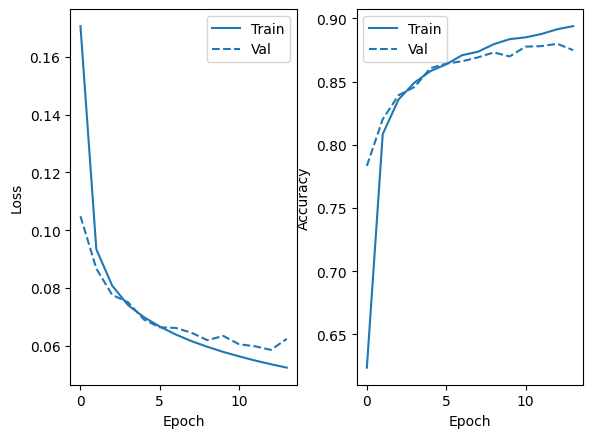

In [10]:
# Plot the training/validation history of our Keras model
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

plot_metrics(history, metrics=['loss','accuracy'])

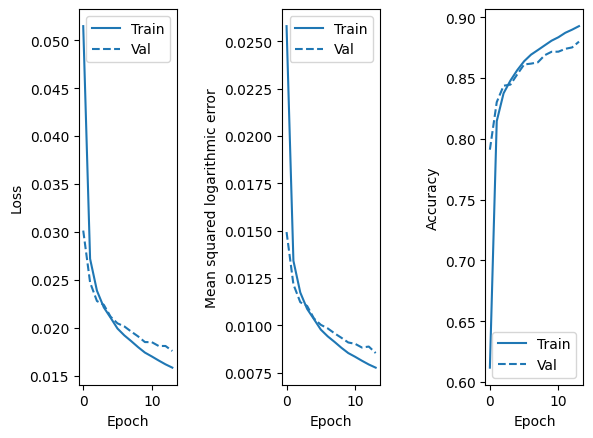

In [11]:
plot_metrics(history2,
             metrics=['loss',
                      'mean_squared_logarithmic_error',
                      'accuracy'])


### Evaluate Metrics
You can use a confusion matrix to summarize the actual vs. predicted labels, where the X axis is the predicted label. A confusion matrix summarizes the actual versus predicted labels, with the predicted labels on the X-axis and the actual labels on the Y-axis. The Y axis is the actual label.

In [12]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [13]:
import sklearn
import seaborn as sns
from sklearn.metrics import confusion_matrix
def plot_cm(labels, predictions):
  cm = confusion_matrix(labels, predictions)
  plt.figure(figsize=(8,8))
  sns.heatmap(cm, annot=True, fmt="d")
  plt.title('Confusion Matrix')
  plt.ylabel('Actual label')
  plt.xlabel('Predicted label')

Assess your model using the test dataset, then present the evaluation metrics and the confusion matrix.

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
loss :  0.06699588894844055

compile_metrics :  0.8665000200271606



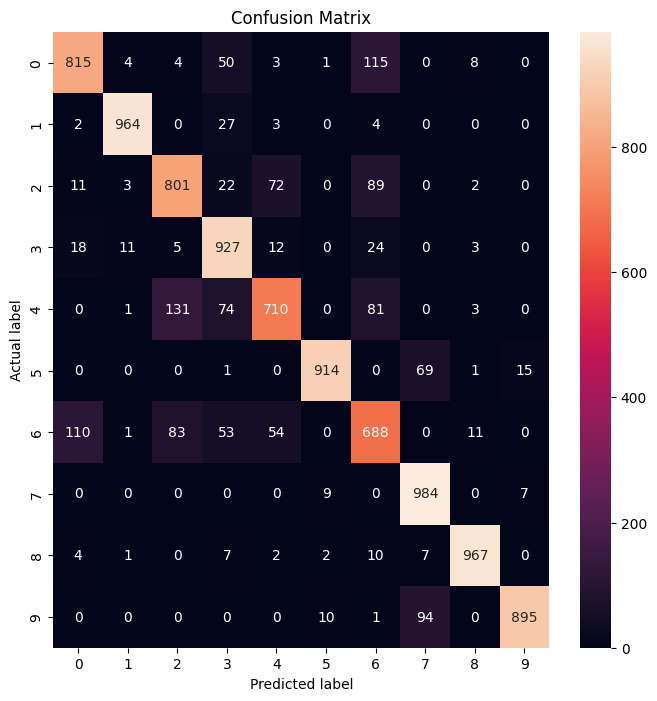

In [14]:
import numpy as np

# Get predictions
y_test_predictions = np.argmax(model.predict(X_test, batch_size=128), axis=1)

# Evaluate model
baseline_results = model.evaluate(X_test, y_test_one_hot,
                                  batch_size=128, verbose=0)

# Print metrics
for name, value in zip(model.metrics_names, baseline_results):
    print(name, ': ', value)
    print()

# Plot confusion matrix
plot_cm(y_test, y_test_predictions)

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
loss :  0.018962176516652107

compile_metrics :  0.009226687252521515



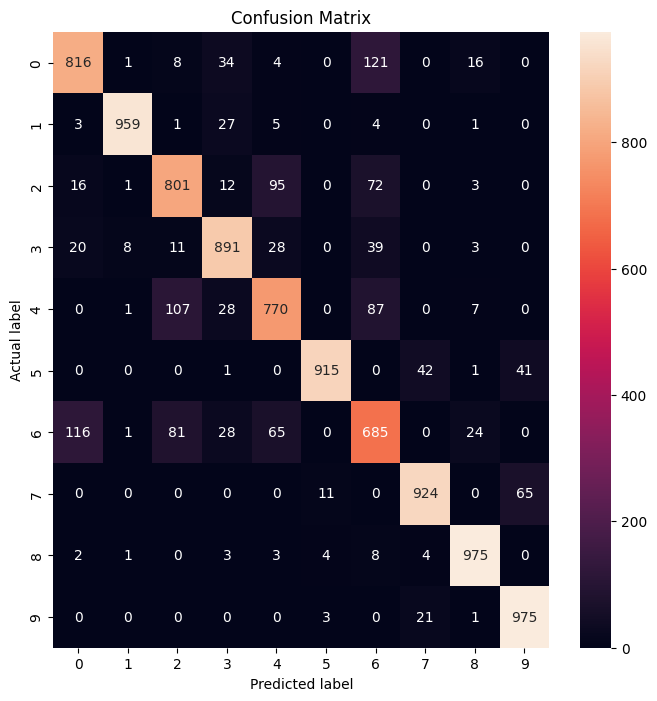

In [15]:
import numpy as np

# Get predictions
y_test_predictions = np.argmax(model2.predict(X_test, batch_size=128), axis=1)

# Evaluate model
baseline_results = model2.evaluate(X_test, y_test_one_hot,
                                   batch_size=128, verbose=0)

# Print evaluation metrics
for name, value in zip(model2.metrics_names, baseline_results):
    print(name, ': ', value)
    print()

# Plot confusion matrix
plot_cm(y_test, y_test_predictions)

### Conclusion
We have successfully trained a Multi-Layer Perceptron using Keras with TensorFlow backend, achieving high validation accuracy.